In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# (1) Cargar los datos

DF=pd.read_json('https://www.datos.gov.co/resource/d7zw-hpf4.json?$limit=1000000&')

DF

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad
0,1996-01-01T00:00:00.000,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1
1,1996-01-01T00:00:00.000,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1
2,1996-01-02T00:00:00.000,5,ANTIOQUIA,5038,ANGOSTURA,SECUESTRO EXTORSIVO,1
3,1996-01-02T00:00:00.000,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1
4,1996-01-02T00:00:00.000,5,ANTIOQUIA,5088,BELLO,SECUESTRO EXTORSIVO,1
...,...,...,...,...,...,...,...
28015,2025-04-16T00:00:00.000,5,ANTIOQUIA,5440,MARINILLA,SECUESTRO EXTORSIVO,1
28016,2025-04-16T00:00:00.000,5,ANTIOQUIA,5440,MARINILLA,SECUESTRO EXTORSIVO,1
28017,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1
28018,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1


In [25]:
# (2) Vista general
DF.info()
print(DF.head())
print(DF.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28020 entries, 0 to 28019
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fecha_hecho   28020 non-null  object
 1   cod_depto     28020 non-null  int64 
 2   departamento  28020 non-null  object
 3   cod_muni      28020 non-null  int64 
 4   municipio     28020 non-null  object
 5   tipo_delito   28020 non-null  object
 6   cantidad      28020 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1.5+ MB
               fecha_hecho  cod_depto  departamento  cod_muni  \
0  1996-01-01T00:00:00.000          5     ANTIOQUIA      5042   
1  1996-01-01T00:00:00.000         25  CUNDINAMARCA     25290   
2  1996-01-02T00:00:00.000          5     ANTIOQUIA      5038   
3  1996-01-02T00:00:00.000         68     SANTANDER     68001   
4  1996-01-02T00:00:00.000          5     ANTIOQUIA      5088   

              municipio          tipo_delito  cantidad  
0  SANTAFE DE AN

In [27]:
# Convertir fecha a datetime
DF['fecha_hecho'] = pd.to_datetime(DF['fecha_hecho'], errors='coerce')

In [31]:
# Convertir cod_muni y cod_depto a string
DF['cod_muni'] = DF['cod_muni'].astype(str)
DF['cod_depto'] = DF['cod_depto'].astype(str)

In [ ]:
print(DF.describe())
print(DF.describe(include=')object')

                         fecha_hecho      cantidad
count                          28020  28020.000000
mean   2003-06-06 02:18:26.980728064      1.002034
min              1996-01-01 00:00:00      1.000000
25%              1999-06-13 00:00:00      1.000000
50%              2001-08-04 00:00:00      1.000000
75%              2004-06-12 00:00:00      1.000000
max              2025-04-21 00:00:00      4.000000
std                              NaN      0.054389
       cod_depto departamento cod_muni    municipio          tipo_delito
count      28020        28020    28020        28020                28020
unique        33           33      974          909                    2
top            5    ANTIOQUIA    11001  BOGOTA D.C.  SECUESTRO EXTORSIVO
freq        4697         4697     1553         1553                17872


In [41]:
DF.groupby('departamento')['cantidad'].sum().sort_values(ascending=False).head(10)

departamento
ANTIOQUIA             4704
CESAR                 2124
VALLE DEL CAUCA       1970
BOGOTA D.C.           1554
SANTANDER             1468
META                  1374
NORTE DE SANTANDER    1368
CUNDINAMARCA          1342
TOLIMA                1151
CAUCA                 1098
Name: cantidad, dtype: int64

In [9]:
DF['año'] = DF['fecha_hecho'].dt.year
DF['mes'] = DF['fecha_hecho'].dt.month

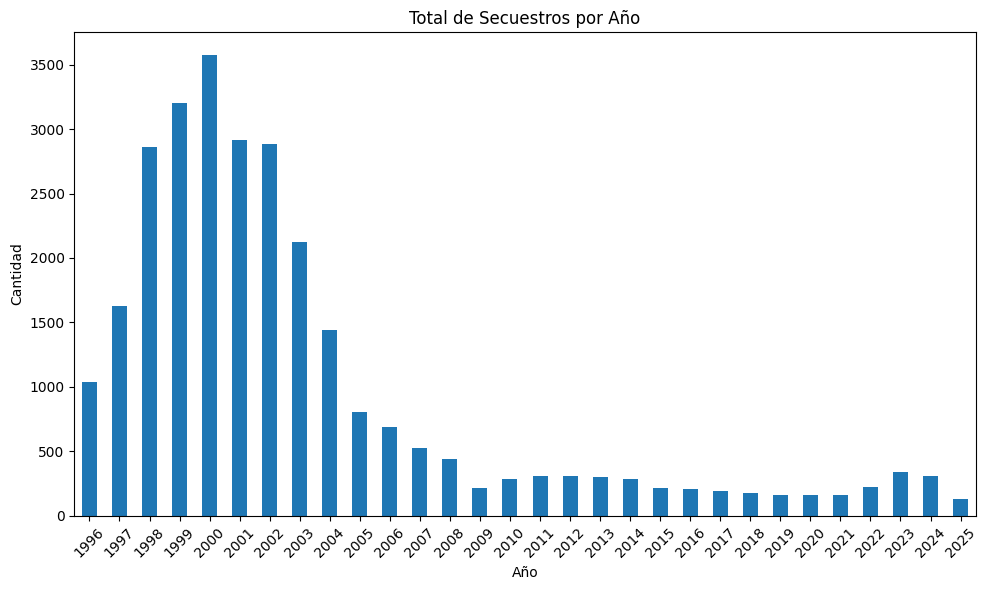

In [10]:
plt.figure(figsize=(10,6))
DF.groupby('año')['cantidad'].sum().plot(kind='bar')
plt.title("Total de Secuestros por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

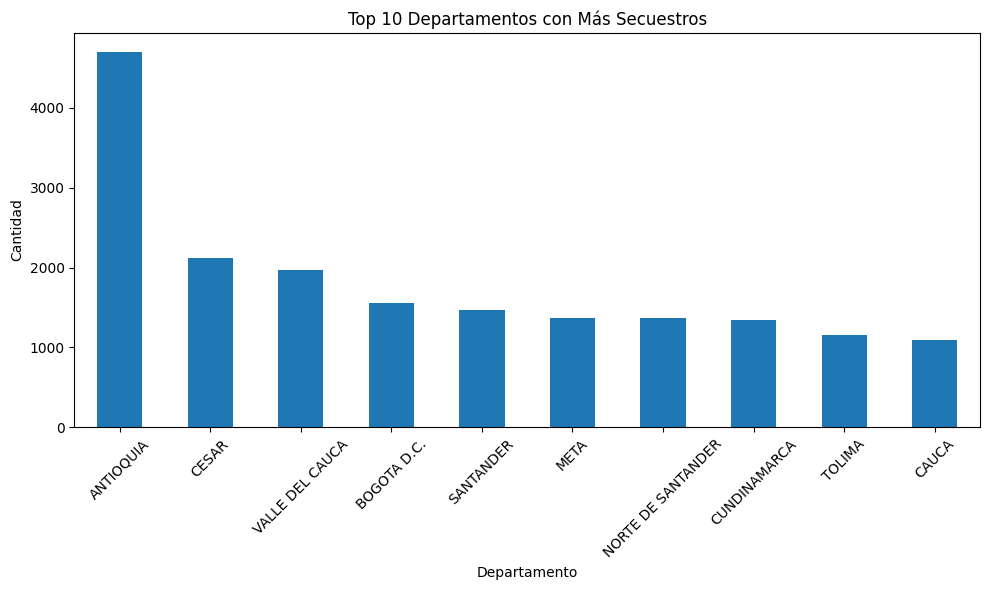

In [11]:
top_departamentos = DF.groupby('departamento')['cantidad'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_departamentos.plot(kind='bar')
plt.title("Top 10 Departamentos con Más Secuestros")
plt.xlabel("Departamento")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

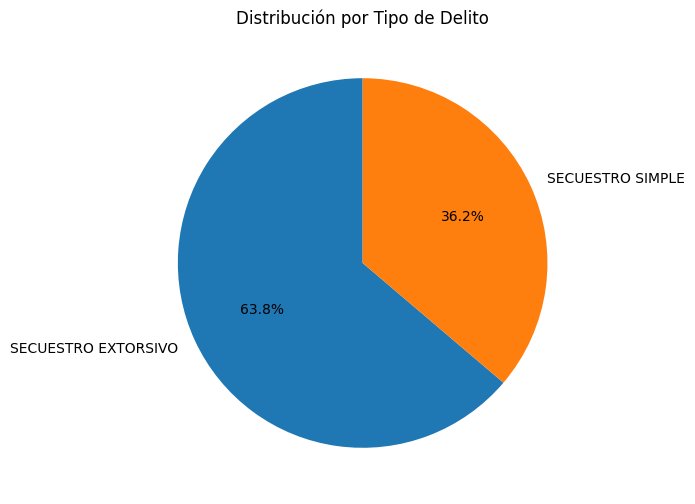

In [12]:
plt.figure(figsize=(6,6))
DF['tipo_delito'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Distribución por Tipo de Delito")
plt.ylabel("")
plt.show()

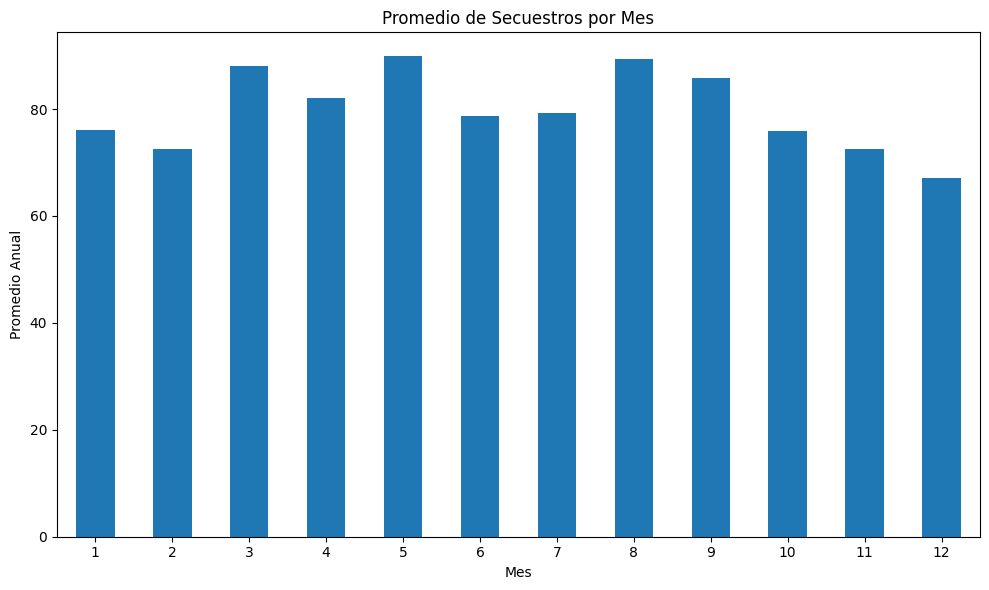

In [13]:
promedio_mensual = DF.groupby(['año', 'mes'])['cantidad'].sum().unstack().mean()

plt.figure(figsize=(10,6))
promedio_mensual.plot(kind='bar')
plt.title("Promedio de Secuestros por Mes")
plt.xlabel("Mes")
plt.ylabel("Promedio Anual")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
DF.head(40)

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad,año,mes
0,1996-01-01,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1,1996,1
1,1996-01-01,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1,1996,1
2,1996-01-02,5,ANTIOQUIA,5038,ANGOSTURA,SECUESTRO EXTORSIVO,1,1996,1
3,1996-01-02,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1,1996,1
4,1996-01-02,5,ANTIOQUIA,5088,BELLO,SECUESTRO EXTORSIVO,1,1996,1
5,1996-01-02,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,1
6,1996-01-03,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,1
7,1996-01-04,63,QUINDIO,63001,ARMENIA,SECUESTRO EXTORSIVO,1,1996,1
8,1996-01-04,18,CAQUETA,18592,PUERTO RICO,SECUESTRO EXTORSIVO,1,1996,1
9,1996-01-04,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO EXTORSIVO,1,1996,1


In [15]:
DF['mes'] = DF['fecha_hecho'].dt.strftime('%B').str.capitalize()

In [16]:
DF.head(20)

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad,año,mes
0,1996-01-01,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1,1996,January
1,1996-01-01,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1,1996,January
2,1996-01-02,5,ANTIOQUIA,5038,ANGOSTURA,SECUESTRO EXTORSIVO,1,1996,January
3,1996-01-02,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1,1996,January
4,1996-01-02,5,ANTIOQUIA,5088,BELLO,SECUESTRO EXTORSIVO,1,1996,January
5,1996-01-02,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,January
6,1996-01-03,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,January
7,1996-01-04,63,QUINDIO,63001,ARMENIA,SECUESTRO EXTORSIVO,1,1996,January
8,1996-01-04,18,CAQUETA,18592,PUERTO RICO,SECUESTRO EXTORSIVO,1,1996,January
9,1996-01-04,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO EXTORSIVO,1,1996,January


In [17]:
import locale
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')

'es_ES.UTF-8'

In [18]:
DF['mes'] = DF['fecha_hecho'].dt.strftime('%B').str.capitalize()

In [19]:
DF.head(20)

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad,año,mes
0,1996-01-01,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1,1996,Enero
1,1996-01-01,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1,1996,Enero
2,1996-01-02,5,ANTIOQUIA,5038,ANGOSTURA,SECUESTRO EXTORSIVO,1,1996,Enero
3,1996-01-02,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1,1996,Enero
4,1996-01-02,5,ANTIOQUIA,5088,BELLO,SECUESTRO EXTORSIVO,1,1996,Enero
5,1996-01-02,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,Enero
6,1996-01-03,11,BOGOTA D.C.,11001,BOGOTA D.C.,SECUESTRO EXTORSIVO,1,1996,Enero
7,1996-01-04,63,QUINDIO,63001,ARMENIA,SECUESTRO EXTORSIVO,1,1996,Enero
8,1996-01-04,18,CAQUETA,18592,PUERTO RICO,SECUESTRO EXTORSIVO,1,1996,Enero
9,1996-01-04,5,ANTIOQUIA,5042,SANTAFE DE ANTIOQUIA,SECUESTRO EXTORSIVO,1,1996,Enero


In [20]:
tabla_delitos = DF.groupby(['departamento', 'tipo_delito'])['cantidad'].sum().unstack(fill_value=0)
tabla_delitos

tipo_delito,SECUESTRO EXTORSIVO,SECUESTRO SIMPLE
departamento,,
AMAZONAS,3,0
ANTIOQUIA,2800,1904
ARAUCA,284,336
ATLANTICO,167,80
BOGOTA D.C.,956,598
BOLIVAR,749,289
BOYACA,347,183
CALDAS,345,111
CAQUETA,476,149


In [21]:
tabla_ordenada = tabla_delitos.sort_values(by='SECUESTRO EXTORSIVO', ascending=False)
tabla_ordenada

tipo_delito,SECUESTRO EXTORSIVO,SECUESTRO SIMPLE
departamento,,
ANTIOQUIA,2800,1904
VALLE DEL CAUCA,1382,588
CESAR,1226,898
SANTANDER,1015,453
BOGOTA D.C.,956,598
NORTE DE SANTANDER,933,435
CUNDINAMARCA,921,421
BOLIVAR,749,289
META,747,627


In [22]:
tabla_delitos = DF.groupby(['departamento', 'tipo_delito'])['cantidad'].sum().unstack(fill_value=0)
tabla_delitos['TOTAL'] = tabla_delitos.sum(axis=1)
tabla_delitos = tabla_delitos.sort_values(by='TOTAL', ascending=False)
tabla_delitos

tipo_delito,SECUESTRO EXTORSIVO,SECUESTRO SIMPLE,TOTAL
departamento,,,
ANTIOQUIA,2800,1904,4704
CESAR,1226,898,2124
VALLE DEL CAUCA,1382,588,1970
BOGOTA D.C.,956,598,1554
SANTANDER,1015,453,1468
META,747,627,1374
NORTE DE SANTANDER,933,435,1368
CUNDINAMARCA,921,421,1342
TOLIMA,661,490,1151


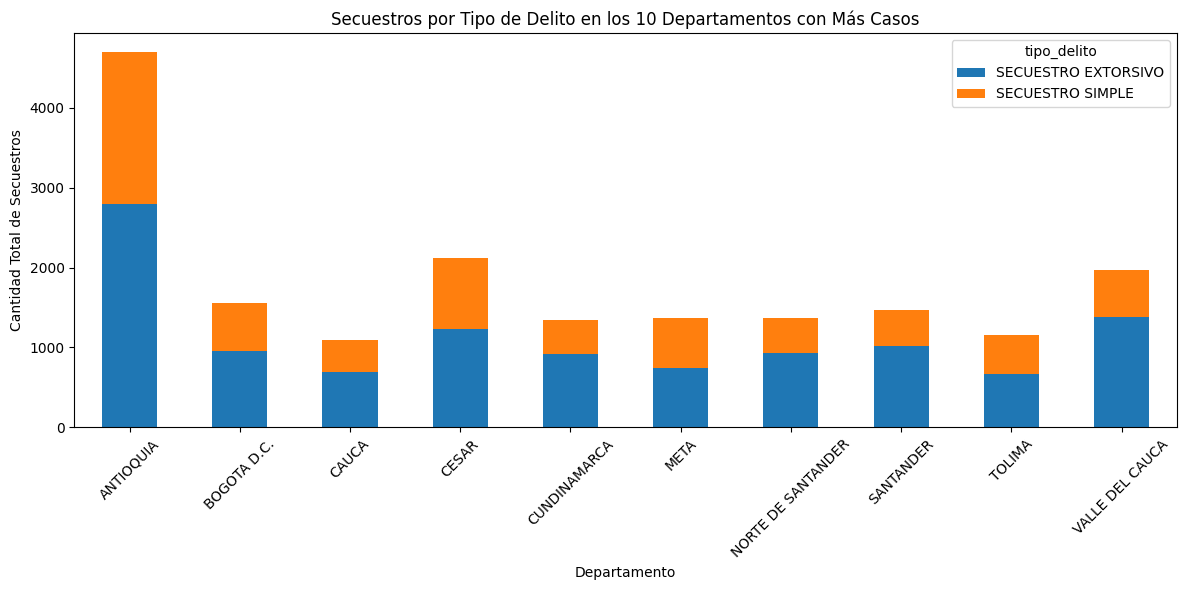

In [23]:
top10 = DF.groupby('departamento')['cantidad'].sum().nlargest(10).index
DF_top = DF[DF['departamento'].isin(top10)]

pivot_top10 = DF_top.groupby(['departamento', 'tipo_delito'])['cantidad'].sum().unstack(fill_value=0)

pivot_top10.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Secuestros por Tipo de Delito en los 10 Departamentos con Más Casos")
plt.xlabel("Departamento")
plt.ylabel("Cantidad Total de Secuestros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()